# (노트) Pytorch Logistic Regression 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

In [797]:
import torch 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

### Example

`-` 현실에서 이런경우가 많음
- $x$가 커질수록 (작아질수록) 성공확률이 증가 

`-` 이러한 모형은 아래와 같이 설계할 수 있음 (왜?) <--- 외우세요.. !!! 

- $y_i \sim Ber(p_i),\quad $ where $p_i=\frac{\exp(\beta_0+\beta_1x_i)}{1+\exp(\beta_0+\beta_1x_i)}$


- $\hat{y}_i= \frac{\exp(\hat{\beta}_0+\hat{\beta}_1 x_i)}{1+\exp(\hat{\beta}_0+\hat{\beta}_1x_i)}=\frac{1}{1+\exp(-\hat{\beta}_0-\hat{\beta}_1x_i)}$

- $loss=  -\sum_{i=1}^{n}\bigg(y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i) \bigg)$ <--- 외우세요!!

In [798]:
X=torch.linspace(-1,1,2000).reshape(2000,1)
β0= -1
β1= 5
u=X*β1+β0
v=torch.exp(u)/(1+(torch.exp(u)+1))
y=torch.bernoulli(v)

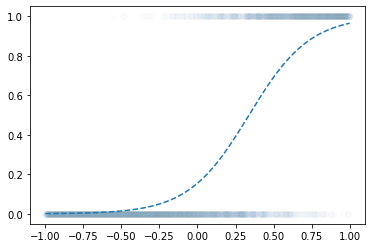

In [799]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,v,'--')

`-` 다이어그램으로 표현하면? 

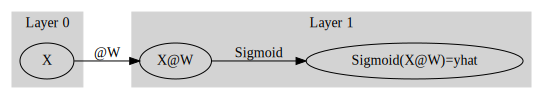

In [800]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "X" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "X" -> "X@W"[label="@W"]
    "X@W" -> "Sigmoid(X@W)=yhat"[label="Sigmoid"]
    label = "Layer 1"
}
''')

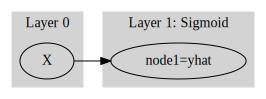

In [801]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    X
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    X -> "node1=yhat"
    label = "Layer 1: Sigmoid"
}
''')

`-` 아키텍쳐, 손실함수, 옵티마이저

In [861]:
torch.manual_seed(43052)
l1=torch.nn.Linear(in_features=1,out_features=1,bias=True)
a1=torch.nn.Sigmoid() 
net=torch.nn.Sequential(l1,a1)
#loss=torch.mean((y-yhat)**2)????? <-- 이거 아닙니다!! 
optimizer=torch.optim.SGD(net.parameters(),lr=0.05)

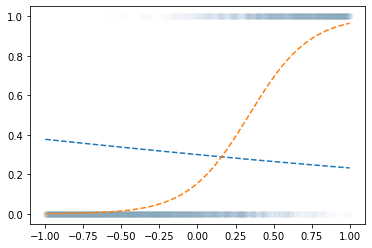

In [862]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,net(X).data,'--')
plt.plot(X,v,'--')

`-` step1~4

In [863]:
for epoc in range(10000):
    ## 1 
    yhat=net(X) 
    ## 2 
    loss=-torch.mean(y*torch.log(yhat)+(1-y)*torch.log(1-yhat))
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.zero_grad()

In [864]:
list(net.parameters())

[Parameter containing:
 tensor([[4.9992]], requires_grad=True),
 Parameter containing:
 tensor([-1.6584], requires_grad=True)]

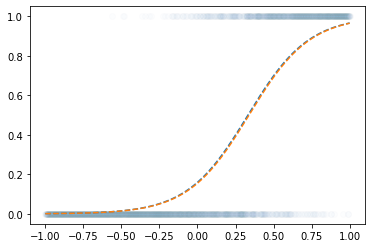

In [865]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,yhat.data,'--')
plt.plot(X,v,'--')

### 숙제 

loss를 mse로 바꿔서 돌려볼것 

In [871]:
torch.manual_seed(43052)
l1=torch.nn.Linear(in_features=1,out_features=1,bias=True)
a1=torch.nn.Sigmoid() 
net=torch.nn.Sequential(l1,a1)
#loss=torch.mean((y-yhat)**2)????? <-- 이거 아닙니다!! 
optimizer=torch.optim.SGD(net.parameters(),lr=0.05)

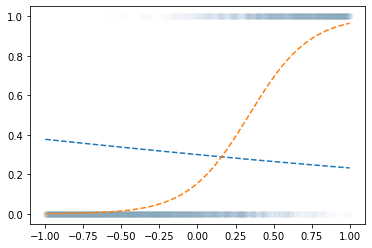

In [872]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,net(X).data,'--')
plt.plot(X,v,'--')

`-` step1~4

In [873]:
for epoc in range(10000):
    ## 1 
    yhat=net(X) 
    ## 2 
    loss=torch.mean((y-yhat)**2)
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.zero_grad()

In [874]:
list(net.parameters())

[Parameter containing:
 tensor([[4.1990]], requires_grad=True),
 Parameter containing:
 tensor([-1.3805], requires_grad=True)]

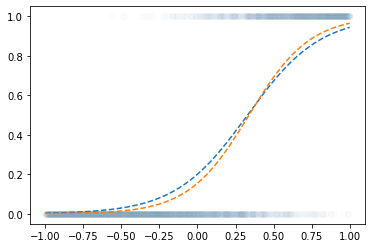

In [875]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,yhat.data,'--')
plt.plot(X,v,'--')